<div align="center">

# 2º PROJETO

| Disciplina | Semestre | Docente | Horário |
| :---: | :---: | :---: | :---: |
| PAM0466 - SISTEMAS INTELIGENTES | 2026.1 | PEDRO THIAGO VALÉRIO DE SOUZA | 3M23 4M45 |

| Discente | Matrícula |
| :---: | :---: |
| ELTON CAIO VIEIRA DE LIMA | 2020010673 |
| LUCAS VIERES ARAÚJO FARIAS | 2025022531 |

</div>

## Atividades

1. No pré-processamento:

(a) Realize o tratamento de valores nulos (verificar especialmente as colunas ca e thal). Caso existam,
escolha o método de imputação através da mediana.

(b) Obtenha a binarização da variável target, transformando os valores originais (0 a 4) em uma variável binária (0 = sem doença, 1 = com doença).

(c) Realize a divisão treino/teste com proporção de 80/20, usando stratify=y para preservar o balanceamento entre as classes.

(d) Faça o escalonamento das *features* numéricas contínuas (age, trestbps, chol, thalach, oldpeak) com StandardScaler.

Dataset utilizado:

In [30]:
!pip install "numpy<2"
!pip install --upgrade matplotlib ipython

# pip install ucimlrepo

from ucimlrepo import fetch_ucirepo 
   
heart_disease = fetch_ucirepo(id=45) 
   
X = heart_disease.data.features 
y = heart_disease.data.targets 
  
print(heart_disease.variables) 

Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable
        name     role         type demographic  \
0        age  Feature      Integer         Age   
1        sex  Feature  Categorical         Sex   
2         cp  Feature  Categorical        None   
3   trestbps  Feature      Integer        None   
4       chol  Feature      Integer        None   
5        fbs  Feature  Categorical        None   
6    restecg  Feature  Categorical        None   
7    thalach  Feature      Integer        None   
8      exang  Feature  Categorical        None   
9    oldpeak  Feature      Integer        None   
10     slope  Feature  Categorical        None   
11        ca  Feature      Integer        None   
12      thal  Feature  Categorical        None   
13       num   Target      Integer        None   

                                          description  units missing_values  
0              

1- a) Realizando o tratamento de valores nulos nas colunas ca e thal.

In [31]:
print(X.isnull().sum())

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
dtype: int64


Neste dataframe, é possível observar que as variáveis <u><strong>ca</strong></u> e <u><strong>thal</strong></u> realmente possuem valores nulos, para tratar desta situação, existem 2 métodos que podem ser aplicados, mas que para esta situação em específico, se faz interessante utilizar do tratamento direcionado apenas nas colunas ca e thal.

In [32]:
X['ca'] = X['ca'].fillna(X['ca'].median())
X['thal'] = X['thal'].fillna(X['thal'].median())


/tmp/ipykernel_18133/1941395062.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['ca'] = X['ca'].fillna(X['ca'].median())
/tmp/ipykernel_18133/1941395062.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['thal'] = X['thal'].fillna(X['thal'].median())


Verificando a aplicação do tratamento:

In [33]:
print(X.isnull().sum())

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
dtype: int64


<hr>

b) Binarização da variável <strong>target</strong>.

In [34]:
print(y.columns)

y = (y['num'] > 0).astype(int)

print(y.value_counts())

Index(['num'], dtype='object')
num
0    164
1    139
Name: count, dtype: int64


Neste caso, os dados classificados como sendo 0 após a binarização, seriam os casos onde nao é originalmente constatada a doença no coração (os dados classificados como 0 no dataframe original), já os demais dados (que variam de 1 a 4 no dataframe) são classificados/binarizados como 1, indicando a presença de doença no coração.

<hr>

c) Realizando a divisão do dataframe entre treino e teste utilizando stratify.

In [35]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

X_train = X_train.copy()
X_test = X_test.copy()

print(f"Treino:\n{y_train.value_counts()}")
print(f"\nTeste:\n{y_test.value_counts()}")

Treino:
num
0    131
1    111
Name: count, dtype: int64

Teste:
num
0    33
1    28
Name: count, dtype: int64


<hr>

d) Escalonamento das *features* utilizando a função StandardsScaller da Sklearn.

In [36]:
from sklearn.preprocessing import StandardScaler

cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

scaler = StandardScaler()

X_train[cols] = scaler.fit_transform(X_train[cols])
X_test[cols]  = scaler.transform(X_test[cols])

print(X_train[cols].mean())
print(X_train[cols].std())

age        -1.835079e-16
trestbps   -3.853667e-16
chol        1.468064e-16
thalach    -7.340318e-18
oldpeak     0.000000e+00
dtype: float64
age         1.002073
trestbps    1.002073
chol        1.002073
thalach     1.002073
oldpeak     1.002073
dtype: float64


<hr>

2. Treinar um modelo de LogisticRegression do scikit-learn utilizando os dados de treino, com os seguintes parâmetros: solver=’liblinear’, random state=42 e max iter=1000. Indique quantas iterações foram necessárias para a convergência do modelo.

In [37]:
from sklearn.linear_model import LogisticRegression

modelo = LogisticRegression(
    solver='liblinear', 
    random_state=42, 
    max_iter=1000
)

modelo.fit(X_train, y_train)

iteracoes = modelo.n_iter_[0]
print(f"Iterações necessárias para a convergência: {iteracoes}")

Iterações necessárias para a convergência: 5


O fato do modelo convergir em somente 5 iterações pode indicar que o tratamento inicial das variáveis, juntamente com o escalonamento e demais tratativas foram eficazes na otimização do modelo de regressão logística.

3. Avaliar o modelo utilizando os dados de teste e calcular as seguintes métricas:

(a) Acurácia.

(b) Precisão.

(c) Recall.

(d) F1-score.

(e) Curva ROC com valor de AUC.

--- MÉTRICAS DE AVALIAÇÃO ---
Acurácia: 0.8689
Precisão: 0.8125
Recall:   0.9286
F1-score: 0.8667

Valor da AUC (Área sob a curva ROC): 0.9545



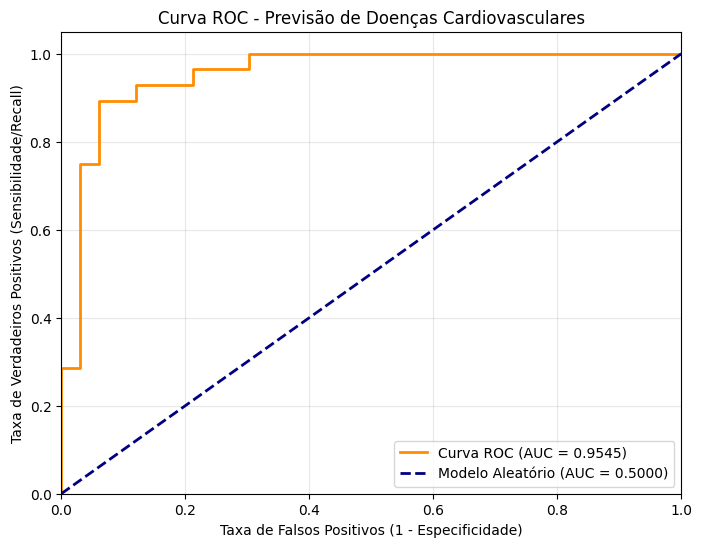

In [38]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_curve, auc
import matplotlib.pyplot as plt

y_pred = modelo.predict(X_test)
y_prob = modelo.predict_proba(X_test)[:, 1]

acuracia = accuracy_score(y_test, y_pred)

precisao = precision_score(y_test, y_pred)

recall = recall_score(y_test, y_pred)

f1 = f1_score(y_test, y_pred)

print("--- MÉTRICAS DE AVALIAÇÃO ---")
print(f"Acurácia: {acuracia:.4f}")
print(f"Precisão: {precisao:.4f}")
print(f"Recall:   {recall:.4f}")
print(f"F1-score: {f1:.4f}\n")

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

print(f"Valor da AUC (Área sob a curva ROC): {roc_auc:.4f}\n")

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Curva ROC (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Modelo Aleatório (AUC = 0.5000)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Taxa de Falsos Positivos (1 - Especificidade)')
plt.ylabel('Taxa de Verdadeiros Positivos (Sensibilidade/Recall)')
plt.title('Curva ROC - Previsão de Doenças Cardiovasculares')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

- Acurácia: o modelo acertou 86.89% de todos os diagnósticos no conjunto de teste.
- Precisão: De todos os pacientes que o modelo classificou como doentes, 81.25% realmente possuíam doença cardíaca.
- Recall: De todos os pacientes que realmente estão doentes, modelo conseguiu identificar 92.86%.
- F1-Score: Equilíbrio entre a precisão e o recall.
- Curva ROC com valor de AUC: O valor de 95.45% indica uma alta capacidade de separação do modelo.